In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Our dataset
data = {
    "Bandgap_eV": [2.8, 1.1, 3.2, 3.4, 3.4, 1.2, 2.2, 2.4, 3.6, 3.6],
    "Application": [
        "Photocatalysis", "Solar cells", "Photocatalysis",
        "LEDs", "LEDs", "Solar cells",
        "Batteries", "Solar cells", "Phosphors", "Gas sensors"
    ]
}

df = pd.DataFrame(data)

# X = input (bandgap), y = output (application)
X = df[["Bandgap_eV"]]
y = df["Application"]

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build the model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Test the model
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("=== ML Model Results ===")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Model Accuracy: {accuracy * 100:.1f}%")
print()

# Predict new materials!
print("=== Predicting New Materials ===")
new_materials = pd.DataFrame({"Bandgap_eV": [1.5, 2.9, 3.5, 0.8]})
new_predictions = model.predict(new_materials)

for bandgap, prediction in zip([1.5, 2.9, 3.5, 0.8], new_predictions):
    print(f"Bandgap {bandgap} eV → Predicted use: {prediction}")

=== ML Model Results ===
Training samples: 8
Testing samples: 2
Model Accuracy: 50.0%

=== Predicting New Materials ===
Bandgap 1.5 eV → Predicted use: Solar cells
Bandgap 2.9 eV → Predicted use: Photocatalysis
Bandgap 3.5 eV → Predicted use: LEDs
Bandgap 0.8 eV → Predicted use: Solar cells


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


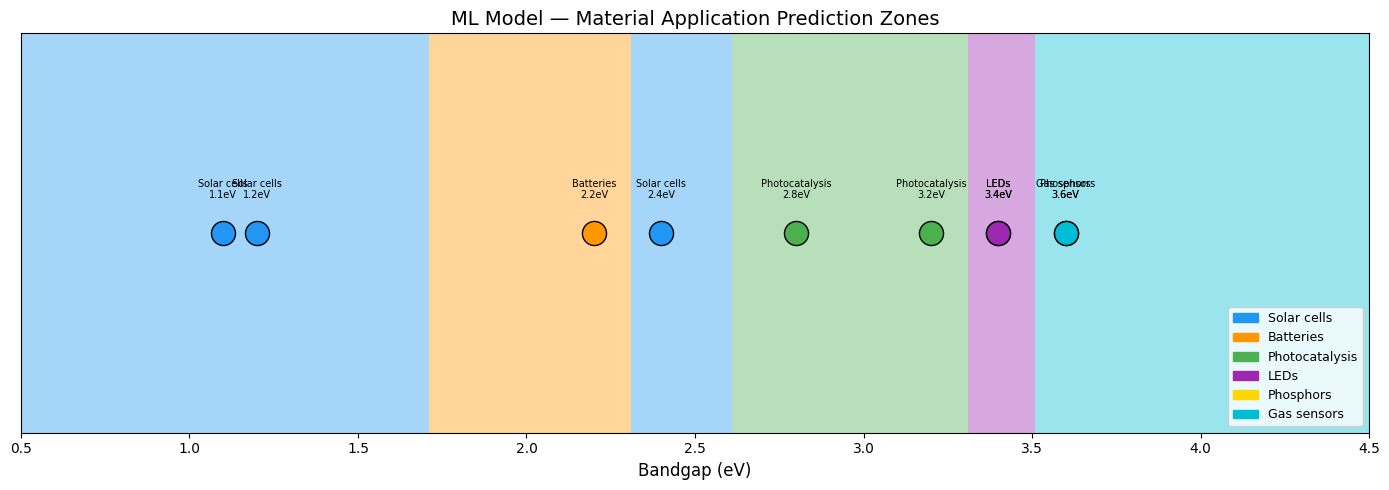

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Zones identified by ML model:
0.5–1.5 eV  → Solar cells & Batteries
2.0–3.0 eV  → Photocatalysis
3.0–4.0 eV  → LEDs, Phosphors & Gas sensors


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Show what the model predicts across all bandgap values
bandgap_range = np.arange(0.5, 4.5, 0.01).reshape(-1, 1)
predicted_apps = model.predict(bandgap_range)

# Assign colors to each application
app_colors = {
    "Solar cells":    "#2196F3",
    "Batteries":      "#FF9800",
    "Photocatalysis": "#4CAF50",
    "LEDs":           "#9C27B0",
    "Phosphors":      "#FFD700",
    "Gas sensors":    "#00BCD4"
}

colors = [app_colors[a] for a in predicted_apps]

plt.figure(figsize=(14, 5))

# Draw colored background zones
for i, (bg, color) in enumerate(zip(bandgap_range.flatten(), colors)):
    plt.axvspan(bg, bg + 0.01, alpha=0.4, color=color, linewidth=0)

# Plot original data points
for _, row in df.iterrows():
    plt.scatter(row["Bandgap_eV"], 0.5,
                color=app_colors[row["Application"]],
                s=300, zorder=5,
                edgecolors='black', linewidth=1)
    plt.annotate(row["Application"] + f'\n{row["Bandgap_eV"]}eV',
                (row["Bandgap_eV"], 0.5),
                textcoords="offset points",
                xytext=(0, 25), ha='center', fontsize=7)

# Legend
patches = [mpatches.Patch(color=c, label=a)
           for a, c in app_colors.items()]
plt.legend(handles=patches, loc='lower right', fontsize=9)

plt.title("ML Model — Material Application Prediction Zones", fontsize=14)
plt.xlabel("Bandgap (eV)", fontsize=12)
plt.xlim(0.5, 4.5)
plt.ylim(0, 1)
plt.yticks([])
plt.tight_layout()
plt.savefig("ml_prediction_zones.png", dpi=150)
plt.show()

from google.colab import files
files.download("ml_prediction_zones.png")

print("\nZones identified by ML model:")
print("0.5–1.5 eV  → Solar cells & Batteries")
print("2.0–3.0 eV  → Photocatalysis")
print("3.0–4.0 eV  → LEDs, Phosphors & Gas sensors")